In [1]:
!pip install -q torch torchvision scikit-learn seaborn

import os, time, copy, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


In [2]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]

extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

!ls /content/dataset

Saving archive (5).zip to archive (5).zip
Dataset extracted successfully!
NEU-DET


In [3]:
TRAIN_PATH = '/content/dataset/NEU-DET/train/images'
TEST_PATH  = '/content/dataset/NEU-DET/validation/images'

CLASSES = ['crazing','inclusion','patches','pitted_surface','rolled-in_scale','scratches']
NUM_CLASSES = 6

In [4]:
def get_loaders(model_name, batch_size=32):
    sz = 299 if model_name == 'InceptionV3' else 224

    train_tf = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    val_tf = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    train_ds = ImageFolder(TRAIN_PATH, transform=train_tf)
    test_ds  = ImageFolder(TEST_PATH,  transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [5]:
def build_model(name):
    if name == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.layer4.parameters():
            p.requires_grad = True
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.fc.in_features, 256),
            nn.ReLU(),
            nn.Linear(256, NUM_CLASSES)
        )

    elif name == 'InceptionV3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.Mixed_7c.parameters():
            p.requires_grad = True
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    elif name == 'EfficientNetB3':
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        for p in model.features[-1].parameters():
            p.requires_grad = True
        model.classifier = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    return model.to(DEVICE)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, is_inception=False):
    model.train()
    total_loss = correct = total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if is_inception:
            out, aux = model(imgs)
            loss = criterion(out, labels) + 0.4 * criterion(aux, labels)
        else:
            out = model(imgs)
            loss = criterion(out, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss/len(loader), correct/total

In [9]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labels)

            probs = torch.softmax(out, 1)

            total_loss += loss.item()
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return total_loss/len(loader), correct/total, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [10]:
EPOCHS = 10
LR = 1e-4

models_list = ['ResNet50','InceptionV3','EfficientNetB3']

all_results = {}
summary = {}

for MODEL_NAME in models_list:

    train_loader, test_loader = get_loaders(MODEL_NAME)
    model = build_model(MODEL_NAME)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = 0
    best_wts = None
    t0 = time.time()

    for epoch in range(EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, MODEL_NAME=='InceptionV3')
        val_loss, val_acc, preds, labels, probs = evaluate(model, test_loader, criterion)

        scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(MODEL_NAME, epoch+1, tr_acc, val_acc)

    elapsed = time.time() - t0

    model.load_state_dict(best_wts)

    _, _, preds, labels, probs = evaluate(model, test_loader, criterion)

    all_results[MODEL_NAME] = (preds, labels, probs)

    report = classification_report(labels, preds, output_dict=True)

    summary[MODEL_NAME] = {
        'accuracy': round(report['accuracy'],4),
        'precision': round(report['weighted avg']['precision'],4),
        'recall': round(report['weighted avg']['recall'],4),
        'f1': round(report['weighted avg']['f1-score'],4),
        'time': round(elapsed,1)
    }

ResNet50 1 0.7020833333333333 0.9
ResNet50 2 0.9847222222222223 0.9944444444444445
ResNet50 3 0.9881944444444445 0.9972222222222222
ResNet50 4 0.9923611111111111 0.9972222222222222
ResNet50 5 0.9965277777777778 0.9972222222222222
ResNet50 6 0.9972222222222222 0.9972222222222222
ResNet50 7 0.9944444444444445 0.9972222222222222
ResNet50 8 0.9986111111111111 0.9972222222222222
ResNet50 9 0.9972222222222222 0.9972222222222222
ResNet50 10 0.9965277777777778 0.9972222222222222
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 186MB/s] 


InceptionV3 1 0.8354166666666667 0.7222222222222222
InceptionV3 2 0.9854166666666667 0.9277777777777778
InceptionV3 3 0.9847222222222223 0.9361111111111111
InceptionV3 4 0.9888888888888889 0.9361111111111111
InceptionV3 5 0.9847222222222223 0.9472222222222222
InceptionV3 6 0.9888888888888889 0.9222222222222223
InceptionV3 7 0.99375 0.9333333333333333
InceptionV3 8 0.9930555555555556 0.9305555555555556
InceptionV3 9 0.9916666666666667 0.9388888888888889
InceptionV3 10 0.99375 0.9361111111111111
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 173MB/s]


EfficientNetB3 1 0.6131944444444445 0.7888888888888889
EfficientNetB3 2 0.9076388888888889 0.8888888888888888
EfficientNetB3 3 0.9527777777777777 0.8861111111111111
EfficientNetB3 4 0.9534722222222223 0.9111111111111111
EfficientNetB3 5 0.9618055555555556 0.925
EfficientNetB3 6 0.9659722222222222 0.9166666666666666
EfficientNetB3 7 0.9631944444444445 0.9138888888888889
EfficientNetB3 8 0.9597222222222223 0.9166666666666666
EfficientNetB3 9 0.9680555555555556 0.9083333333333333
EfficientNetB3 10 0.9694444444444444 0.9277777777777778


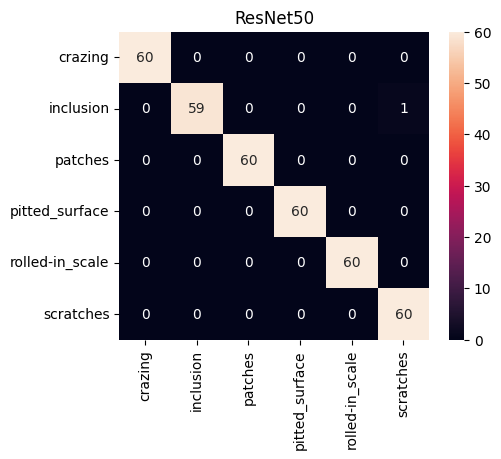

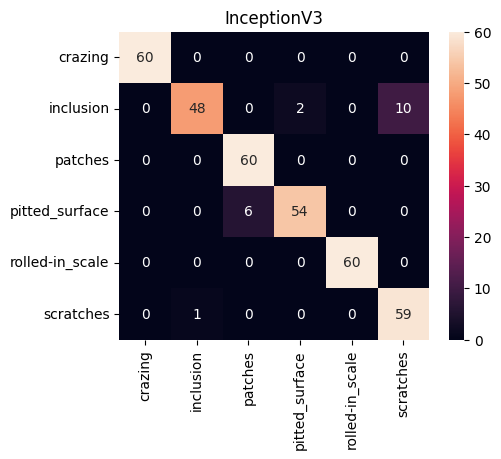

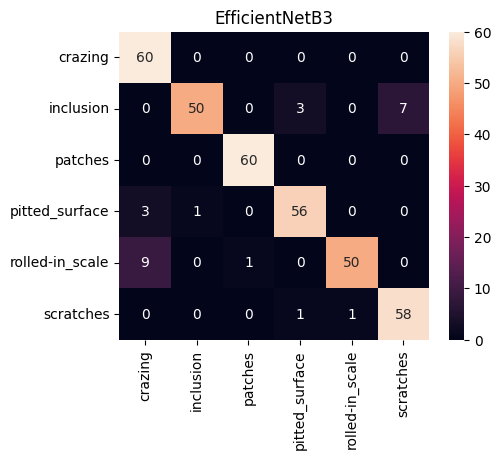

In [11]:
for name,(preds,labels,_) in all_results.items():
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(name)
    plt.show()

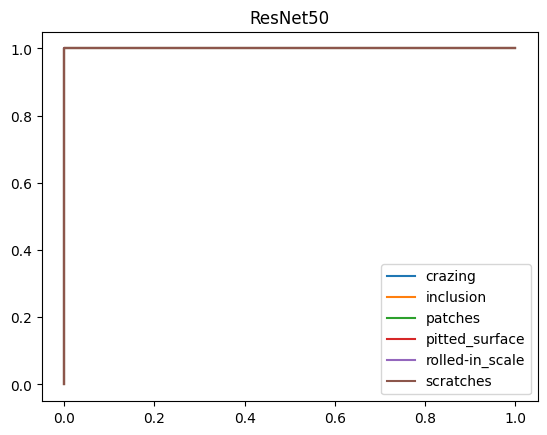

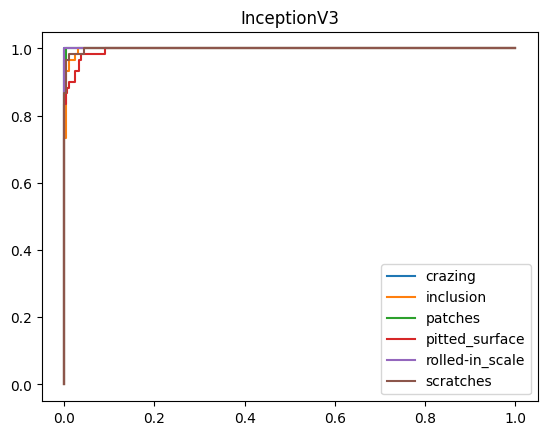

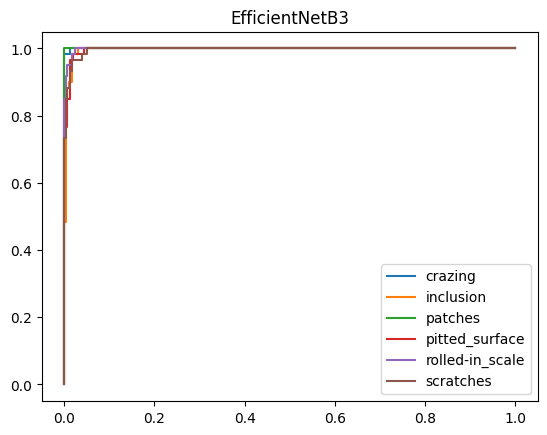

In [12]:
for name,(_,labels,probs) in all_results.items():
    lb = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    plt.figure()
    for i in range(NUM_CLASSES):
        fpr,tpr,_ = roc_curve(lb[:,i], probs[:,i])
        plt.plot(fpr,tpr,label=CLASSES[i])
    plt.title(name)
    plt.legend()
    plt.show()

In [13]:
print(summary)

best_model = max(summary, key=lambda x: summary[x]['accuracy'])
print("Best Model:", best_model)

{'ResNet50': {'accuracy': 0.9972, 'precision': 0.9973, 'recall': 0.9972, 'f1': 0.9972, 'time': 134.1}, 'InceptionV3': {'accuracy': 0.9472, 'precision': 0.9513, 'recall': 0.9472, 'f1': 0.9465, 'time': 172.3}, 'EfficientNetB3': {'accuracy': 0.9278, 'precision': 0.9339, 'recall': 0.9278, 'f1': 0.9273, 'time': 104.3}}
Best Model: ResNet50
